In [3]:
import pyshtools as sh
import cmcrameri.cm as cm
import cartopy.crs as ccrs
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)  # to ignore cartopy warnings

### compute rotation avg of B crust

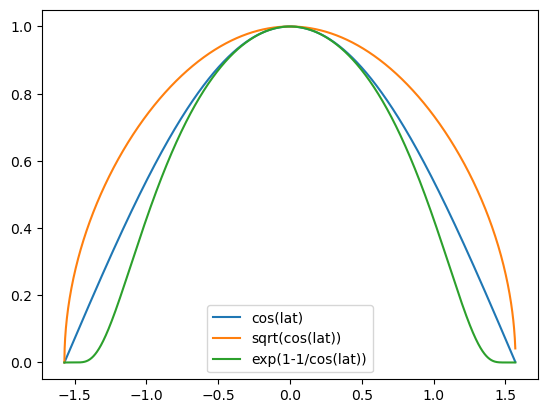

In [4]:
lat = np.arange(-90,90,0.1)
lat = np.deg2rad(lat)
plt.plot(lat,np.cos(lat), label='cos(lat)')
plt.plot(lat,np.sqrt(np.cos(lat)),label='sqrt(cos(lat))')
plt.plot(lat, np.exp(1-1/np.cos(lat)), label='exp(1-1/cos(lat))')

plt.legend()


C:\Users\Timothee Delcourt\AppData\Local\Temp\ipykernel_18904\1496583210.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(b, b+1/(b))


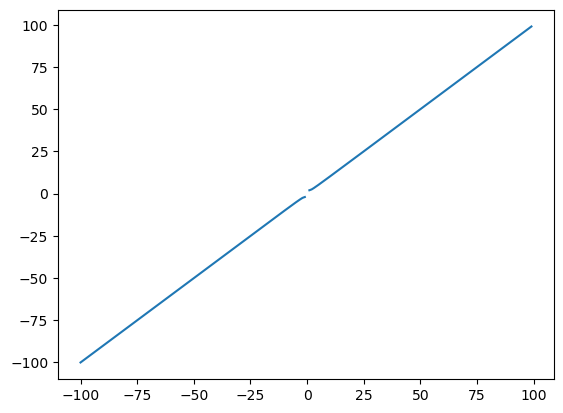

In [255]:
b = np.arange(-100,100,1)
plt.plot(b, b+1/(b))

In [14]:
def plot_rotation_avg(season=None, savefig=False, savecoeffs=False):

    d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
    d25 = d25.change_ref(3393.5e3+150e3)
    # expansion = d25.expand()
    # # colorbar scale = log
    # expansion.plot_total(projection=ccrs.Robinson(central_longitude=180),
    #                     cmap_scale='log', 
    #                     cmap=cm.lajolla, 
    #                     cmap_reverse=True, 
    #                     cmap_limits=[1e-1,1e3],
    #                     grid=False,
    #                     tick_interval=[60,30],
    #                     xlabel='Longitude (degrees)',
    #                     ylabel='Latitude (degrees)',
    # )

    coeffs_rotation = d25.coeffs.copy()
    alphas = list(np.arange(0.1,360,0.1))
    n = len(alphas)+1
    for alpha in alphas:
        coeffs_rotation += d25.rotate(alpha,0,0).coeffs
    coeffs_rotation /= n
    coeffs_rotation = sh.SHMagCoeffs.from_array(coeffs_rotation,r0=d25.r0)

    # season = 'summer' # 'summer', 'winter', 'spring', 'autumn' or None
    if season == 'summer':
        coeffs_rotation = coeffs_rotation.rotate(0,25,0)
    elif season == 'winter':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,0)
    elif season == 'autumn':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,-90, convention='x')
    elif season == 'spring':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,90, convention='x')
    elif season == None:
        season = ''
    if season is not None:
        season = '_'+season

    if savecoeffs:
        coeffs_rotation.to_file(f'../crustal_field_model/PINN2025_rotation_avg{season}.sh') # bug, winter -> summer

    expansion_rotation = coeffs_rotation.expand()
    total_field = expansion_rotation.total
    # multiply by np.exp(-1/cos_lat) to account for the ionospheric currents being stronger at the equator
    # total field is a Driscoll and Healy (1994) sampled grids. So latitudes are equally spaced from -90 to 90
    latitudes = np.linspace(-90,90,281 )
    _, latitudes = np.meshgrid(np.linspace(0,360,561),latitudes)
    cos_lat = np.cos(np.deg2rad(latitudes))
    factor = np.exp(1-1/cos_lat)
    grid_final = total_field.data * factor
    grid_final = sh.SHGrid.from_array(grid_final,grid='DH')
    fig, ax = grid_final.plot(projection=ccrs.Robinson(central_longitude=180),
                                    cmap_scale='log', 
                                    # cmap=cm.lajolla, 
                                    cmap=cm.imola, 
                                    cmap_reverse=False,
                                    grid=True,
                                    tick_interval=[90,30],
                                    cmap_limits=[1e-1,1e2],
                                    # colorbar='right',
    )
    if savefig:
        fig.savefig(f'../figures/rotation_avg/crustal_field_rotation_avg{season}_chapmanprod_v2.png',dpi=300)
        plt.close()
    else:
        plt.show()
    

    

In [15]:
# plot_rotation_avg('summer')

for season in ['spring', 'autumn', None, 'summer', 'winter']:
    plot_rotation_avg(season, savefig=True, savecoeffs=False)

### compare B_crust_avg and J

In [282]:
import pandas as pd

def get_B_and_J(season):
    
    crustal_field = pd.read_csv(f'../predictions/crustal_field_rotation_avg_{season}_150km_fibonacci.csv')
    print(crustal_field.shape)
    if season == 'winter':
        current_field = pd.read_csv(f'../predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_winter.csv')
    elif season == 'summer':
        current_field = pd.read_csv(f'../predictions/PINN_MSO_ensemble_models_1to30_150km_fibonacci_summer.csv')
    elif season == 'autumn':
        current_field = pd.read_csv(f'../predictions/PINN_MSO_ensemble_models_1to31_150km_fibonacci_automn.csv')
    elif season == 'spring':
        current_field = pd.read_csv(f'../predictions/PINN_MSO_ensemble_models_1to11_150km_fibonacci_spring.csv')

    deg_max = 85
    condition = (crustal_field['lat'] <= 60) & (crustal_field['lat'] >= -60) & (crustal_field['lon'] >= -deg_max) & (crustal_field['lon'] <= deg_max)
    # condition = (crustal_field['lon'] >= -95) & (crustal_field['lon'] <= 95)

    crustal_field = crustal_field[condition]
    current_field = current_field[condition]
    print(crustal_field.shape)
    Jtotal = 0.0
    for i in ['p','t']: #['x','y','z']: #
        Jtotal += (current_field['J'+i].values)**2
    Jtotal = np.sqrt(Jtotal)
    current_field['Jtotal'] = Jtotal

    cos_lat = np.cos(np.deg2rad(crustal_field['lat'].values))
    crustal_field['B_chapman'] = (crustal_field['B'].values) * np.exp(1-1/cos_lat)
    # J_h = np.sqrt(current_field['Jp'].values**2 + current_field['Jt'].values**2)

    return crustal_field['B_chapman'].values, current_field['Jtotal'].values
    return crustal_field['B'].values, current_field['Jtotal'].values
    B_h = np.sqrt(crustal_field['Bp'].values**2 + crustal_field['Bt'].values**2)
    B_h_scaled = B_h * np.exp(1-1/cos_lat)
    return B_h_scaled, current_field['Jp'].values

# plt.xscale('log')

In [283]:
# season = 'spring'  # 'spring', 'autumn', None, 'summer', 'winter'
B_scaled_seasons = []
J_seasons = []
for season in ['spring', 'autumn', 'summer', 'winter']:
    B_scaled, J = get_B_and_J(season)
    B_scaled_seasons.append(B_scaled)
    J_seasons.append(J)

B_scaled = np.concatenate(B_scaled_seasons)
J = np.concatenate(J_seasons)
J = abs(J)

(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)
(900000, 7)
(368059, 7)


In [198]:
def remove_outliers(x):
    IQR = np.percentile(x, 75) - np.percentile(x, 25)
    lower_bound = np.percentile(x, 25) - 1.5 * IQR
    upper_bound = np.percentile(x, 75) + 1.5 * IQR
    return (x >= lower_bound) & (x <= upper_bound)

(1472236,) (1472236,)


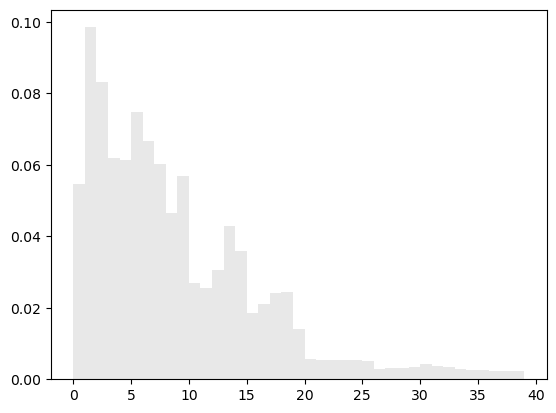

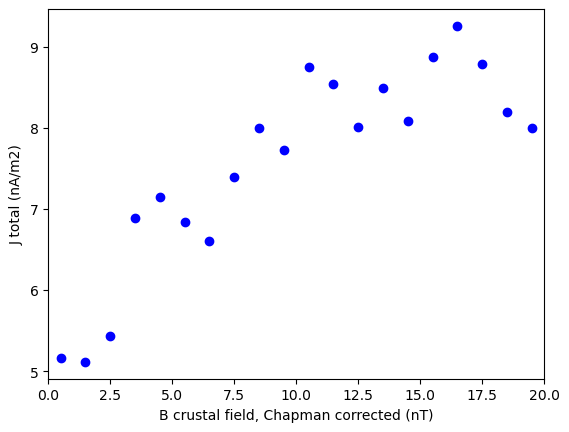

In [ ]:
# plot bars of J vs B bins
print(B_scaled.shape, J.shape)
# condition = remove_outliers(B_scaled) & remove_outliers(J)
# B_scaled, J = B_scaled[condition], J[condition]
# print(B_scaled.shape, J.shape)
plt.figure()
B_bins = np.arange(0,40,1)
J_means = []
J_std = []
for i in range(len(B_bins)-1):
    bin_mask = (B_scaled >= B_bins[i]) & (B_scaled < B_bins[i+1])
    J_mean = np.mean(J[bin_mask])
    J_means.append(J_mean)
    J_std.append(np.std(J[bin_mask]))
plt.hist(B_scaled, bins=B_bins, color='lightgray', alpha=0.5, density=True)

plt.figure()
# plt.errorbar(B_bins[:-1]+0.5, J_means, yerr=J_std, fmt='o', color='blue')
plt.scatter(B_bins[:-1]+0.5, J_means, color='blue')
plt.xlim(0,20)
plt.xlabel('B crustal field, Chapman corrected (nT)')
plt.ylabel('J total (nA/m2)')
# plt.savefig('../figures/rotation_avg/Jtotal_vs_B_chapman_rotation_avg_4seasons_max20.png', dpi=300)

(1234080,) (1234080,)


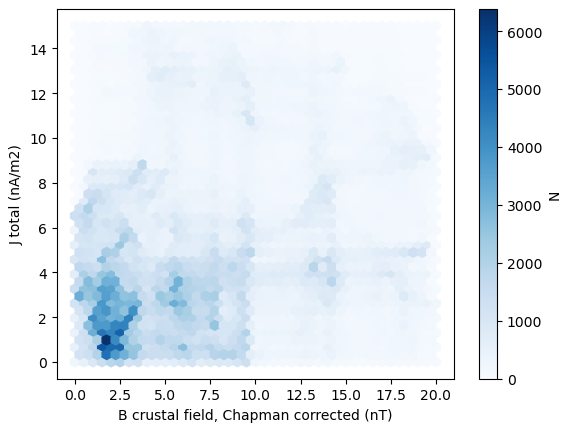

In [194]:
print(B_scaled.shape, J.shape)
# condition = remove_outliers(B_scaled) & remove_outliers(J)
# B_scaled, J = B_scaled[condition], J[condition]
# print(B_scaled.shape, J.shape)
# B_scaled = crustal_field['B_chapman'].values
# J = current_field['Jtotal'].values
# drop = 20
# B_scaled = B_scaled[::drop]
# J = J[::drop]
J = abs(J)
# plt.figure()
# plt.scatter(B_scaled, J, s=1, alpha=1)
# plt.xlabel('B crustal field, Chapman corrected (nT)')
# plt.ylabel('J total (nA/m2)')

# density plot
plt.figure()
plt.hexbin(B_scaled, J, gridsize=40, cmap='Blues',  extent=(0,20,0,15)) #bins='log',vmin=500,
# plt.hist2d(B_scaled, J, cmap='Blues',bins = 50, range=[[0,20],[0,20]])
plt.xlabel('B crustal field, Chapman corrected (nT)')
plt.ylabel('J total (nA/m2)')
plt.colorbar(label='N')
# plt.xlim(-1, 30)
# plt.axis('equal')



### playground

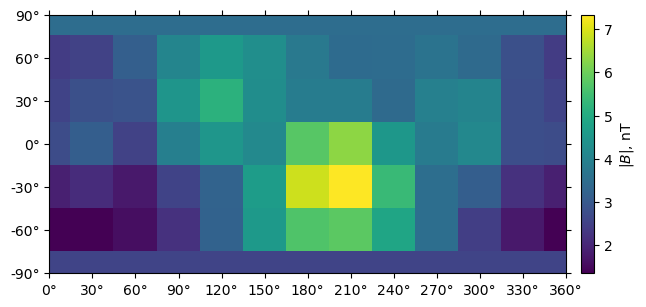

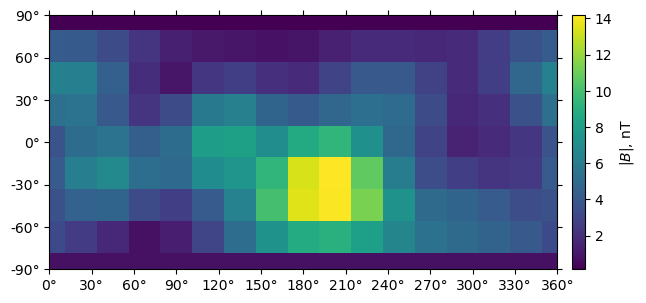

Error in callback <function flush_figures at 0x000001A39FB05940> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [16]:
l_list = list(range(2, 20))
l_list.append(134)
for l in l_list:
    l19 = sh.datasets.Mars.Langlais2019(lmax=l)
    expansion = l19.expand()
    expansion.plot_total()